<a href="https://colab.research.google.com/github/joshna-pinto/YuvaIntern-Week4-Supervised-Learning/blob/main/YuvaIntern_Week4_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Week 4: Supervised Learning Model Implementation
# YuvaIntern - Virtual Data Science with Python

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumn information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Survived"].value_counts())

Dataset shape: (891, 12)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare      

In [ ]:
# Feature engineering

data = df.copy()

# Create FamilySize
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

# Create IsAlone
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

# Remove columns that are not directly used for the initial model
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Handle missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

print("Missing values after preprocessing:")
print(data.isnull().sum())

print("\nDataset after feature engineering:")
print(data.head())

Missing values after preprocessing:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

Dataset after feature engineering:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  \
0         0       3    male  22.0      1      0   7.2500        S           2   
1         1       1  female  38.0      1      0  71.2833        C           2   
2         1       3  female  26.0      0      0   7.9250        S           1   
3         1       1  female  35.0      1      0  53.1000        S           2   
4         0       3    male  35.0      0      0   8.0500        S           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


In [ ]:
# Convert categorical variables into numerical form

data_encoded = pd.get_dummies(
    data,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Convert True/False values to 0/1
data_encoded = data_encoded.astype(int)

print("Encoded dataset:")
print(data_encoded.head())

print("\nColumns after encoding:")
print(data_encoded.columns.tolist())

Encoded dataset:
   Survived  Pclass  Age  SibSp  Parch  Fare  FamilySize  IsAlone  Sex_male  \
0         0       3   22      1      0     7           2        0         1   
1         1       1   38      1      0    71           2        0         0   
2         1       3   26      0      0     7           1        1         0   
3         1       1   35      1      0    53           2        0         0   
4         0       3   35      0      0     8           1        1         1   

   Embarked_Q  Embarked_S  
0           0           1  
1           0           0  
2           0           1  
3           0           1  
4           0           1  

Columns after encoding:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [ ]:
# Recreate encoded data while preserving numerical precision

data_encoded = pd.get_dummies(
    data,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

# Separate features (X) and target (y)
X = data_encoded.drop("Survived", axis=1)
y = data_encoded["Survived"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):
   Pclass   Age  SibSp  Parch     Fare  FamilySize  IsAlone  Sex_male  \
0       3  22.0      1      0   7.2500           2        0         1   
1       1  38.0      1      0  71.2833           2        0         0   
2       3  26.0      0      0   7.9250           1        1         0   
3       1  35.0      1      0  53.1000           2        0         0   
4       3  35.0      0      0   8.0500           1        1         1   

   Embarked_Q  Embarked_S  
0           0           1  
1           0           0  
2           0           1  
3           0           1  
4           0           1  

Target (y):
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

Feature shape: (891, 10)
Target shape: (891,)


In [ ]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (712, 10)
Testing set: (179, 10)

Training target distribution:
Survived
0    439
1    273
Name: count, dtype: int64

Testing target distribution:
Survived
0    110
1     69
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data scaled shape:", X_train_scaled.shape)
print("Testing data scaled shape:", X_test_scaled.shape)

Training data scaled shape: (712, 10)
Testing data scaled shape: (179, 10)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test_scaled)

# Probability of survival
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Results")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Evaluation Results
------------------------
Accuracy : 0.8045
Precision: 0.7833
Recall   : 0.6812
F1-Score : 0.7287
ROC-AUC  : 0.8502

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:
[[97 13]
 [22 47]]


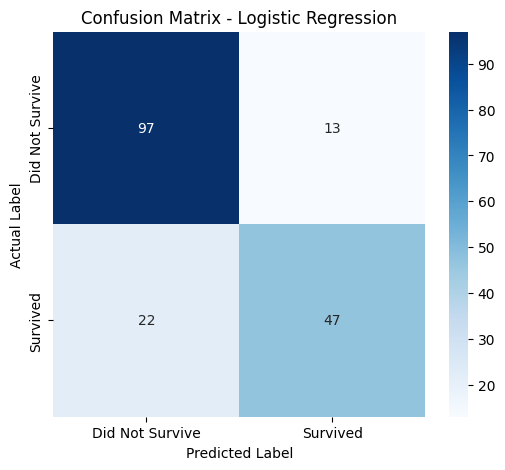

In [ ]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation accuracy scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation accuracy scores:
[0.8041958  0.79020979 0.8028169  0.77464789 0.81690141]

Mean CV Accuracy: 0.7977543583177387
Standard Deviation: 0.014314751873939172


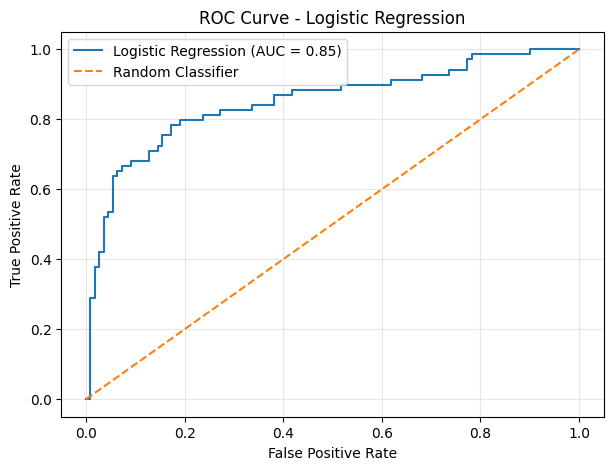

In [ ]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Analyze Logistic Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Feature coefficients:")
print(coefficients)

Feature coefficients:
      Feature  Coefficient  Absolute_Coefficient
7    Sex_male    -1.233756              1.233756
0      Pclass    -0.892297              0.892297
1         Age    -0.486951              0.486951
6     IsAlone    -0.310395              0.310395
2       SibSp    -0.287828              0.287828
5  FamilySize    -0.224979              0.224979
9  Embarked_S    -0.139335              0.139335
8  Embarked_Q     0.106667              0.106667
4        Fare     0.085013              0.085013
3       Parch    -0.062279              0.062279


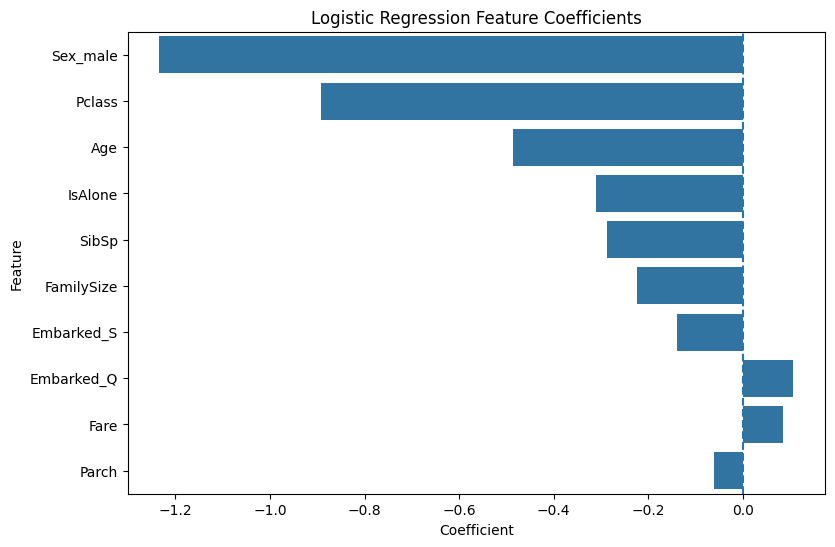

In [ ]:
# Visualize Logistic Regression coefficients

plt.figure(figsize=(9, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.axvline(0, linestyle="--")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Evaluation")
print("------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Evaluation
------------------------
Accuracy : 0.7933
Precision: 0.8333
Recall   : 0.5797
F1-Score : 0.6838
ROC-AUC  : 0.8435


In [ ]:
# 5-fold cross-validation for Random Forest

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Random Forest cross-validation accuracy scores:")
print(rf_cv_scores)

print("\nMean RF CV Accuracy:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest cross-validation accuracy scores:
[0.82517483 0.78321678 0.85211268 0.79577465 0.8028169 ]

Mean RF CV Accuracy: 0.8118191667487442
Standard Deviation: 0.02432490170494511


In [ ]:
# Compare both supervised learning models

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

print(comparison.round(4))

      Metric  Logistic Regression  Random Forest
0   Accuracy               0.8045         0.7933
1  Precision               0.7833         0.8333
2     Recall               0.6812         0.5797
3   F1-Score               0.7287         0.6838
4    ROC-AUC               0.8502         0.8435


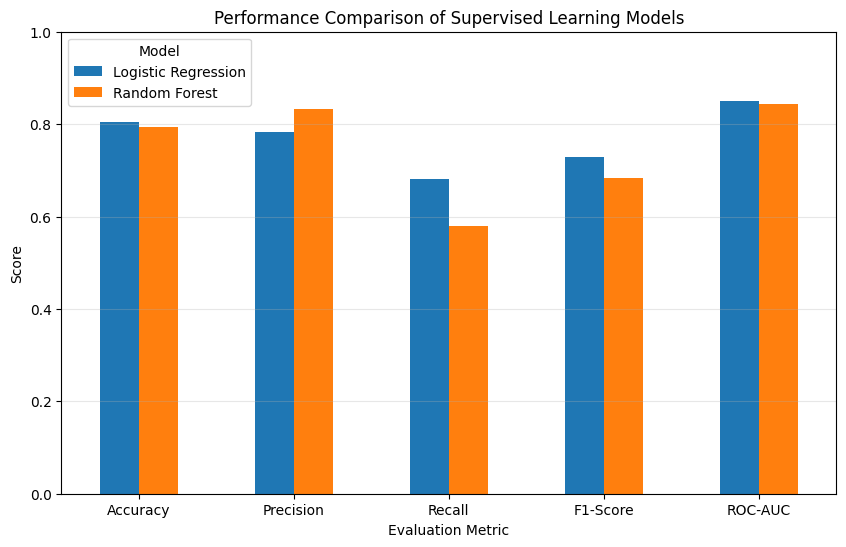

In [ ]:
# Model Performance Comparison

comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Supervised Learning Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(rf_importance)

Random Forest Feature Importance:
      Feature  Importance
7    Sex_male    0.423691
4        Fare    0.177380
0      Pclass    0.130896
1         Age    0.108161
5  FamilySize    0.061405
2       SibSp    0.026814
9  Embarked_S    0.025021
3       Parch    0.020375
6     IsAlone    0.015150
8  Embarked_Q    0.011107


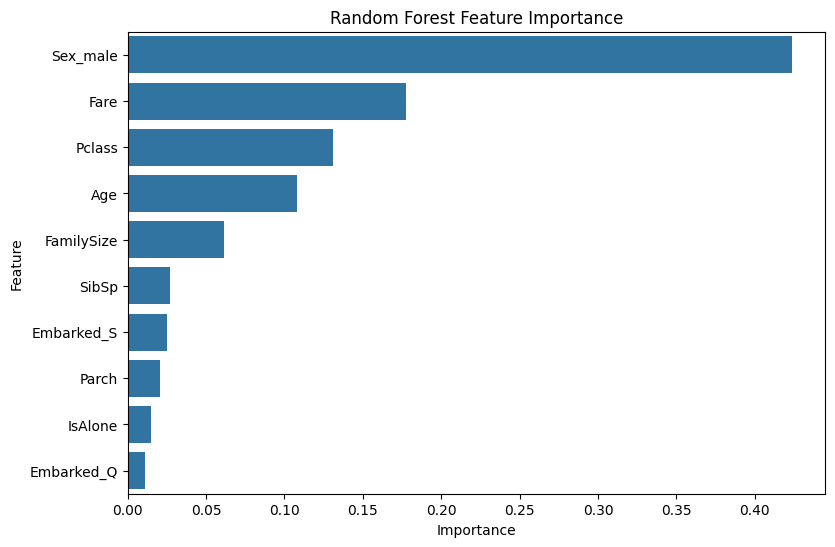

In [ ]:
# Visualize Random Forest Feature Importance

plt.figure(figsize=(9, 6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()